In [1]:
from diffrax import ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from time import perf_counter
from algorithms.EKI import EnsembleKalmanInversion

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[CpuDevice(id=0)]


In [2]:
beta = jnp.log(0.4)
eta = jnp.log(1/7)
gamma = jnp.log(1/14) #0.07
q= jnp.log(0.1)
mu = jnp.log(0.01)

par_true = jnp.array([beta,eta,gamma,q,mu])

t_vec = jnp.linspace(0,100,100)

def SEIR(t,y,args):
  beta,eta,gamma,q,mu = args

  beta = jnp.exp(beta)
  eta = jnp.exp(eta)
  gamma = jnp.exp(gamma)
  q = jnp.exp(q)
  mu = jnp.exp(mu)

  S,E,I,R = y
  N = S+E+I+R

  dS = - beta * ((E + q * I)/N) * S
  dE = beta * ((E + q * I)/N) * S - eta*E - gamma * E
  dI = eta * E - gamma * I - mu * I
  dR = gamma * E + gamma * I


  return jnp.array([dS,dE,dI,dR])

In [3]:
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(SEIR),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller=diffrax.PIDController(1e-3,1e-3)
        )
  return solution.ys

rng_key = jax.random.PRNGKey(0)

y_true = model(t_vec,jnp.array([5000,1.,1.,0]),(beta,eta,gamma,q,mu))

key = jax.random.key(0)

key,I_noise_key = jax.random.split(key)
data_newI = jax.random.poisson(I_noise_key,jnp.exp(eta) * y_true[:,1] + 0.005)

key,D_noise_key = jax.random.split(key)
data_newD = jax.random.poisson(D_noise_key,jnp.exp(mu) * y_true[:,2] + 0.005)


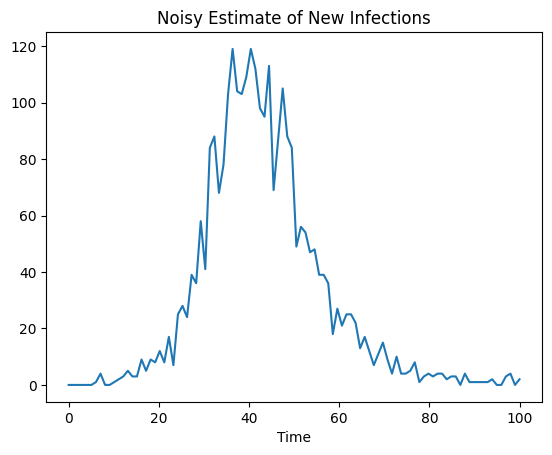

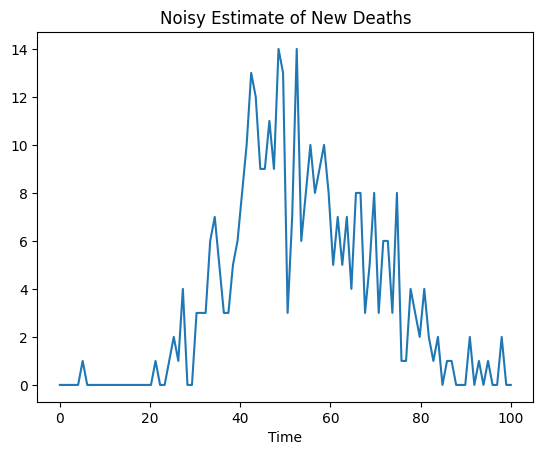

In [4]:
plt.title('Noisy Estimate of New Infections')
plt.plot(t_vec,data_newI)
plt.xlabel('Time')
plt.show()

plt.title('Noisy Estimate of New Deaths')
plt.xlabel('Time')
plt.plot(t_vec,data_newD)
plt.show()

In [5]:
observations = jnp.concatenate(
    (data_newI[..., jnp.newaxis], data_newD[..., jnp.newaxis]), axis=-1
).reshape(-1)


In [6]:
def map(par, _):
    full_state = jnp.maximum(model(t_vec, jnp.array([5000, 1.0, 1.0, 0]), par), 1e-6)

    data_newI = jnp.maximum(jnp.exp(eta) * full_state[:, 1], 1e-6)

    data_newD = jnp.maximum(jnp.exp(mu) * full_state[:, 2], 1e-6)

    return jnp.concatenate(
        (data_newI[..., jnp.newaxis], data_newD[..., jnp.newaxis]), axis=-1
    ).reshape(-1)

In [7]:
rng_key, noise_key = jax.random.split(rng_key)

dim_output = len(par_true)
gamma = 100 * jnp.eye(len(observations))

num_ensemble_members = 100

rng_key, init_ensemble_key, init_key = jax.random.split(rng_key, 3)

beta = jnp.log(0.4)
eta = jnp.log(1/7)
gamma = jnp.log(1/14) #0.07
q= jnp.log(0.1)
mu = jnp.log(0.01)

initial_ensemble = jnp.log(jnp.array([0.2,0.2,0.1,0.05,0.05])) + jax.random.normal(
    init_ensemble_key, (num_ensemble_members, dim_output)
)

(final_ensemble,_), _ = EnsembleKalmanInversion(
    initial_ensemble,
    observations,
    gamma,
    lambda x, y: jax.vmap(map, in_axes=(0, 0))(x, y),
    0.01,
    init_key,
)

par_estimate = jnp.mean(final_ensemble,axis = 0)

print(jnp.exp(par_estimate))
print(f"Relative Error: {jnp.abs(par_true - par_estimate)/par_true}")

[0.40946335 0.15032552 0.06395286 0.06780401 0.01952234]
Relative Error: [-0.02551902 -0.02618719 -0.04189056 -0.16874462 -0.14526594]
